# Generalised least squares applied to the log-law velocity profile

This notebook demonstrates how to:
1. Generate a synthetic turbulent boundary layer profile
2. Propagate measurement uncertainties
3. Perform a GLS fit of the log-law
4. Visualise the confidence region of the parameters

In [1]:
import numpy as np
import bl_profile as bl
import hot_wire as hw
import fit_tools as ft
import stats_tools as st
import plot_tools as pt
from dataclasses import dataclass

## Define the input covariance dataclass

In [2]:
@dataclass
class in_cov:
    e_u: float
    e_u_tau: float
    e_nu: float
    e_q: float
    e_rho: float
    e_v: float
    s_z0: float
    s_dz: float

## Generate synthetic turbulent boundary layer data

In [3]:
Re_tau = 10000
delta = 0.1
nu = 1.51e-5
z_plus = hw.z(Re_tau, 30, 10)
u_plus = bl.composite(z_plus, Re_tau)
z_plus_range = [3 * Re_tau**0.5, 0.15 * Re_tau]

## Propagate measurement uncertainties

In [4]:
cov = in_cov(
    e_u=0.001,
    e_u_tau=0.005,
    e_nu=0.006,
    e_q=0.002,
    e_rho=0.003,
    e_v=0.001,
    s_z0=10e-6,
    s_dz=1e-6
)

## Perform GLS fit

In [5]:
# Fit log law
z_plus_crop, u_plus_crop, n = bl.crop_log(
    z_plus,
    u_plus,
    z_plus_range[0],
    z_plus_range[1]
)
fit = ft.fit(Re_tau, delta, nu, z_plus_crop, u_plus_crop, cov)

# Compute statistics
stats = st.get_stats(fit)
st.report(stats)

# Unpack results
A = stats.A
kappa = stats.kappa
xi = stats.xi
eta = stats.eta


GLS log-law fit report
  A        : 4.0956 [ -0.2902,   0.2902]
  κ        : 0.3814 [ -0.0087,   0.0091]
  ρ(κ, A)  : 0.4931
  p-value  : 0.7885  ✓ Good fit (p > 0.05)


## Plot viscous-normalised velocity profile

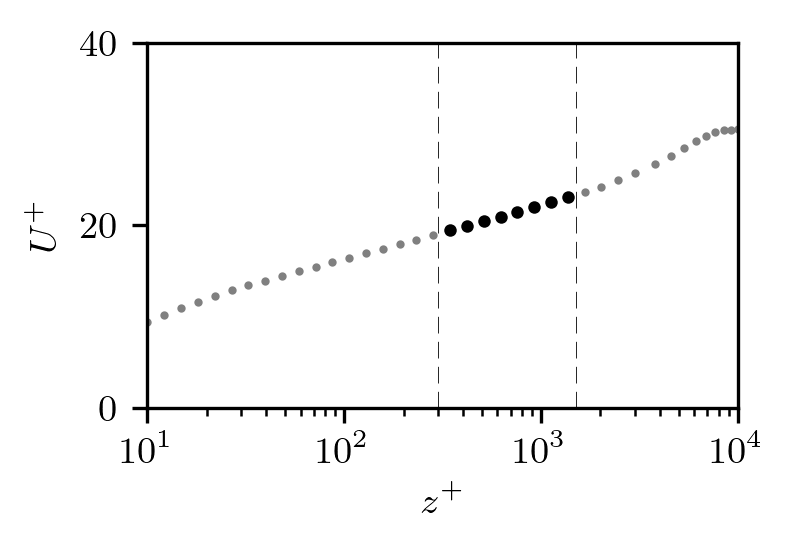

In [8]:
fig1, ax1 = pt.make_axes(
    70,
    [15, 5, 10, 5],
    [10, Re_tau],
    [0, 40],
    r'$z^+$',
    r'$U^+$',
    yticks=[0, 20, 40],
    xscale='log'
)
ax1.plot([3 * Re_tau**0.5, 3 * Re_tau**0.5], ax1.get_ylim(), color='k', linewidth=0.2, linestyle=(0, (20, 10)))
ax1.plot([0.15 * Re_tau, 0.15 * Re_tau], ax1.get_ylim(), color='k', linewidth=0.2, linestyle=(0, (20, 10)))
ax1.plot(z_plus, u_plus, 'o', markersize=2, markerfacecolor='gray', markeredgecolor='none', linestyle='none')
ax1.plot(z_plus_crop, u_plus_crop, 'o', markersize=3, markerfacecolor='k', markeredgecolor='none', linestyle='none')

## Plot joint uncertainty region of log-law parameters

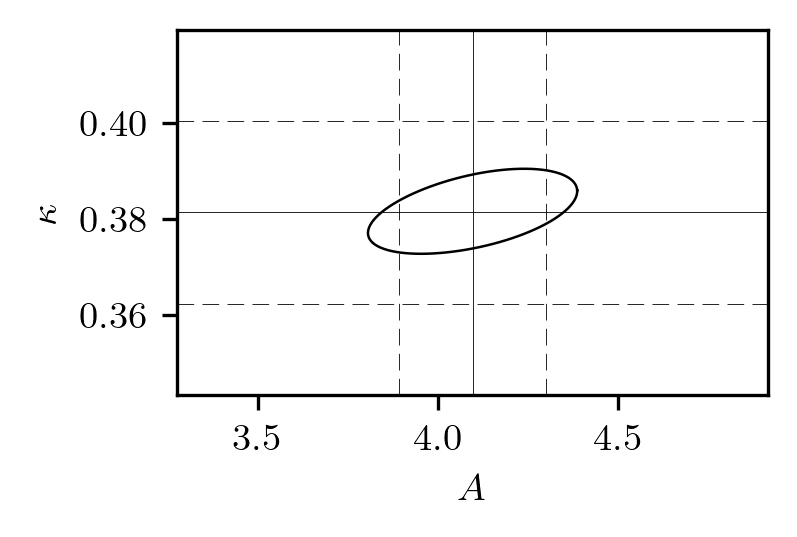

In [7]:
fig2, ax2 = pt.make_axes(
    70,
    [15, 5, 10, 5],
    [0.8 * A, 1.2 * A],
    [0.9 * kappa, 1.1 * kappa],
    r'$A$',
    r'$\kappa$'
)
ax2.plot(ax2.get_xlim(), [kappa, kappa], color='k', linewidth=0.2)
ax2.plot([A, A], ax2.get_ylim(), color='k', linewidth=0.2)
for x in [0.95 * A, 1.05 * A]:
    ax2.plot([x, x], ax2.get_ylim(), color='k', linewidth=0.2, linestyle=(0, (20, 10)))
for y in [0.95 * kappa, 1.05 * kappa]:
    ax2.plot(ax2.get_xlim(), [y, y], color='k', linewidth=0.2, linestyle=(0, (20, 10)))
ax2.plot(xi, 1 / eta, color='k', linewidth=0.6)